This notebook uses the precomputed dielectric functions in [dielectric_functions](../dielectric_functions/) to compute DM-electron scattering rates, electron recoil spectra, and sensitivity projections

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

# Either install qcdark2 as a python package
from qcdark2 import dark_matter_rates as dm

# Or just download dark_matter_rates.py
#import sys
#sys.path.append('../../QCDark2')
#import qcdark2.dark_matter_rates as dm

import plot_templates as pl

## Dielectric Function

In [2]:
epsilon = dm.load_epsilon('../dielectric_functions/composite/Si_comp.h5')

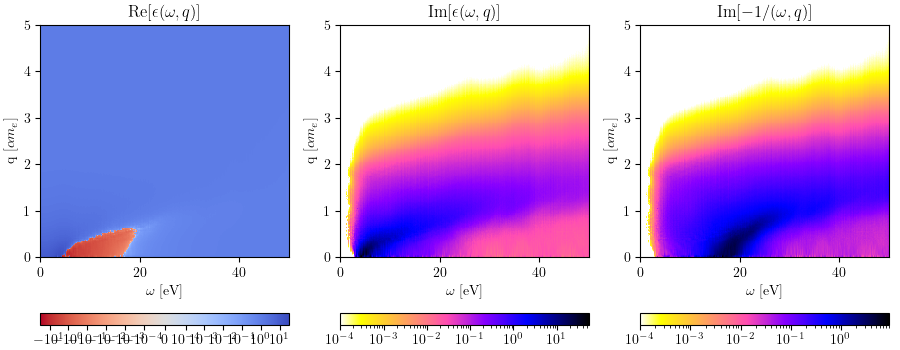

In [3]:
ax = pl.plot_epsilon(epsilon)
for axi in ax:
    axi.set_ylim([0,5])

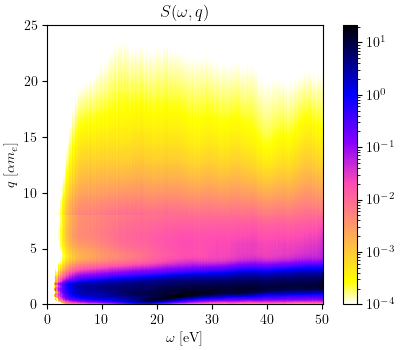

In [4]:
ax = pl.plot_dynamic_structure_factor(epsilon)

In [5]:
epsilon_nolfe = dm.load_epsilon('../dielectric_functions/nolfe/Si_nolfe.h5')
epsilon_lfe = dm.load_epsilon('../dielectric_functions/lfe/Si_lfe.h5')

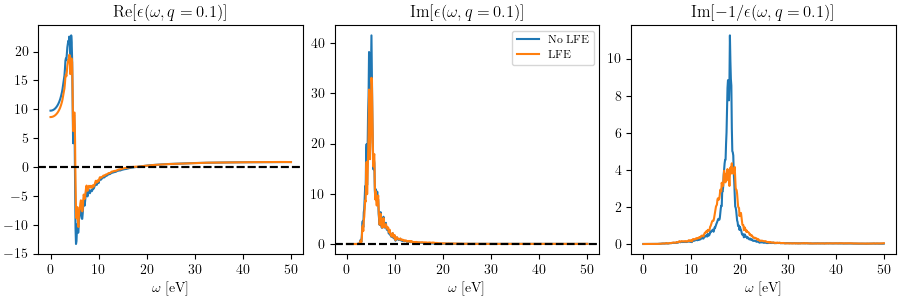

In [6]:
ax = pl.plot_dielectric_function_q(epsilon_nolfe, label='No LFE', q=0.1)
ax = pl.plot_dielectric_function_q(epsilon_lfe, label='LFE', ax=ax, q=0.1)

## Halo DM

### Scattering rate

In [7]:
# DM parameters
m_X = 1e9 # 1 GeV

In [8]:
dR_dE_light, E = dm.get_dR_dE(epsilon, m_X=m_X, mediator='light', astro_model=dm.default_astro, screening='RPA')
dR_dE_heavy, E = dm.get_dR_dE(epsilon, m_X=m_X, mediator='heavy', astro_model=dm.default_astro, screening='RPA')

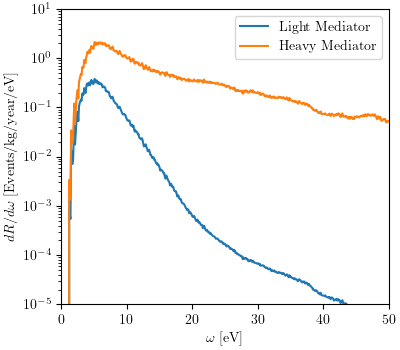

In [ ]:
plt.figure(figsize=(4,3.5), layout='constrained')
plt.plot(E, dR_dE_light, label='Light Mediator')
plt.plot(E, dR_dE_heavy, label='Heavy Mediator')
plt.yscale('log')
plt.xlabel(r'$\omega$ [eV]')
plt.ylabel(r'$dR/d\omega$ [Events/kg/year/eV]')
plt.ylim([1e-5,10])
plt.xlim([0,50])
plt.legend()

### Electron recoil spectrum

In [10]:
ionization_file = 'external_files/p100K.dat' # Ramanathan & Kurinsky ionization yield: 2004.10709 (https://link.aps.org/doi/10.1103/PhysRevD.102.063026)

R_Q_light = dm.recoil_spectrum(dR_dE_light, ionization_file=ionization_file, E_max=50, dE=0.1)
R_Q_heavy = dm.recoil_spectrum(dR_dE_heavy, ionization_file=ionization_file, E_max=50, dE=0.1)

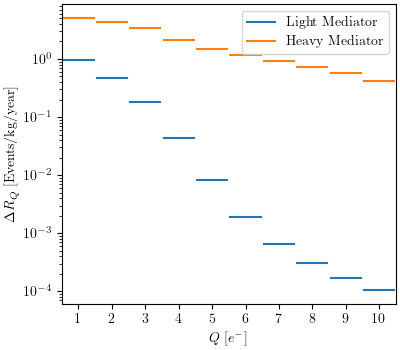

In [11]:
ax = pl.plot_recoil_spectrum(R_Q_light, label='Light Mediator', Q_max=10)
ax = pl.plot_recoil_spectrum(R_Q_heavy, label='Heavy Mediator', ax=ax, Q_max=10)

### Sensitivity projection

In [12]:
# For 90% confidence level
m_X_list, sigma_e_light = dm.ex(epsilon, mediator='light', astro_model=dm.default_astro, screening='RPA', cl=0.9, m_X_min=5e5, m_X_max=1e9, N_m_X=20)
m_X_list, sigma_e_heavy = dm.ex(epsilon, mediator='heavy', astro_model=dm.default_astro, screening='RPA', cl=0.9, m_X_min=5e5, m_X_max=1e9, N_m_X=20)

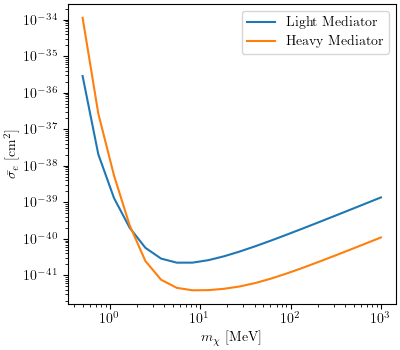

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(4,3.5), layout='constrained')
ax.plot(m_X_list/1e6, sigma_e_light, label='Light Mediator')
ax.plot(m_X_list/1e6, sigma_e_heavy, label='Heavy Mediator')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_{\chi}$ [MeV]')
ax.set_ylabel(r'$\bar{\sigma_e}$ [$\mathrm{cm^2}$]')
plt.legend()

## Solar-reflected DM

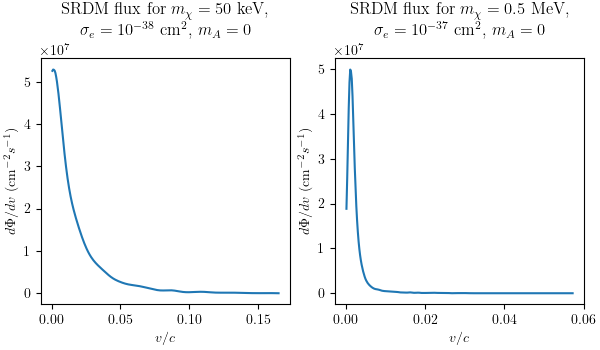

In [14]:
# SRDM fluxes for light mediators from 2404.10066 (https://doi.org/10.1088/1475-7516/2024/07/023)

# m_X = 50 keV, sigma_e = 1e-38 cm^2
flux_file_50k = np.genfromtxt('external_files/Differential_SRDM_Flux_DPLM_10_8.txt')
v_srdm_50k = flux_file_50k[1:,0]/dm.lightSpeed
flux_srdm_50k = flux_file_50k[1:,1]*dm.lightSpeed

# m_X = 0.5 MeV, sigma_e = 1e-37 cm^2
flux_file_05M = np.genfromtxt('external_files/Differential_SRDM_Flux_DPLM_15_20.txt')
v_srdm_05M = flux_file_05M[1:,0]/dm.lightSpeed
flux_srdm_05M = flux_file_05M[1:,1]*dm.lightSpeed

fig, ax = plt.subplots(1, 2, figsize=(6, 3.5), layout='constrained')
ax[0].plot(v_srdm_50k, flux_srdm_50k)
ax[1].plot(v_srdm_05M, flux_srdm_05M)

ax[0].set_title(r'SRDM flux for $m_{\chi} = 50$ keV,'+'\n'+r'$\sigma_e = 10^{-38}$ $\mathrm{cm}^2$, $m_A = 0$')
ax[1].set_title(r'SRDM flux for $m_{\chi} = 0.5$ MeV,'+'\n'+r'$\sigma_e = 10^{-37}$ $\mathrm{cm}^2$, $m_A = 0$')

for axi in ax:
    axi.set_xlabel(r'$v/c$')
    axi.set_ylabel(r'$d\Phi/dv$ ($\mathrm{cm}^{-2}s^{-1}$)')


### Scattering rates

In [15]:
dR_dE_50k = dm.get_rate_flux(epsilon, m_X=50e3, sigma_e=1e-38, flux=flux_srdm_50k, v_list=v_srdm_50k, m_A=0, mediator='vector', screening='RPA')
dR_dE_05M = dm.get_rate_flux(epsilon, m_X=0.5e6, sigma_e=1e-37, flux=flux_srdm_05M, v_list=v_srdm_05M, m_A=0, mediator='vector', screening='RPA')

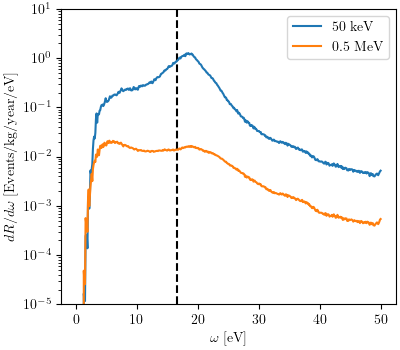

In [16]:
E = epsilon.E
fig, ax = plt.subplots(1, 1, figsize=(4,3.5), layout='constrained')
ax.axvline(16.6, color='k', linestyle='--') # plasmon peak at q -> 0
ax.plot(E, dR_dE_50k, label='50 keV')
ax.plot(E, dR_dE_05M, label='0.5 MeV')

ax.set_yscale('log')
ax.set_ylim([1e-5, 10])
ax.set_xlabel(r'$\omega$ [eV]')
ax.set_ylabel(r'$dR/d\omega$ [Events/kg/year/eV]')
plt.legend()

### Electron recoil spectrum

In [17]:
ionization_file = 'external_files/p100K.dat' # Ramanathan & Kurinsky ionization yield: 2004.10709 (https://link.aps.org/doi/10.1103/PhysRevD.102.063026)

R_Q_50k = dm.recoil_spectrum(dR_dE_50k, ionization_file=ionization_file, E_max=50, dE=0.1)
R_Q_05M = dm.recoil_spectrum(dR_dE_05M, ionization_file=ionization_file, E_max=50, dE=0.1)

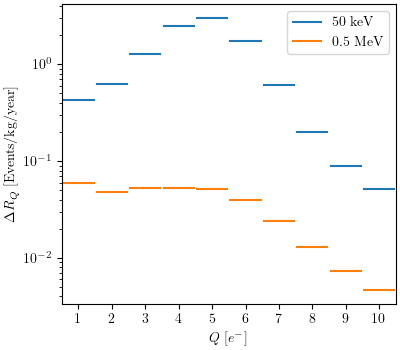

In [19]:
ax = pl.plot_recoil_spectrum(R_Q_50k, label='50 keV', Q_max=10)
ax = pl.plot_recoil_spectrum(R_Q_05M, label='0.5 MeV', ax=ax, Q_max=10)